In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
def modelSolution(t, N0, r, K):
    return 1/(1/K + (1/N0 - 1/K)*np.exp(-r*t))

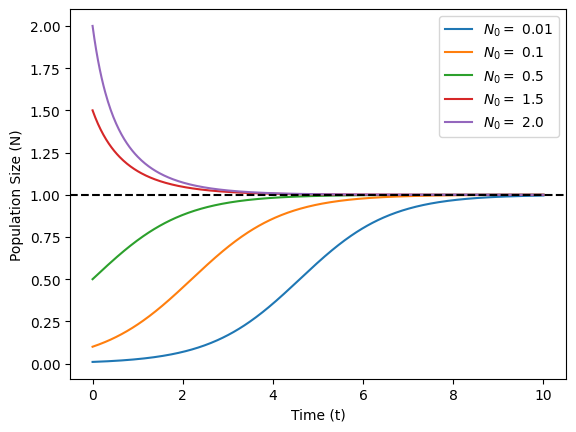

In [10]:
t = np.linspace(0, 10, 500)
r = 1
K = 1

fig, ax =  plt.subplots()
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K

for N0 in N0s:
    N = modelSolution(t, N0, r, K)
    ax.plot(t, N, label=rf"$N_0 =$ {N0}")
ax.axhline(y = K, color = 'k', linestyle = '--')
ax.set_xlabel("Time (t)")
ax.set_ylabel("Population Size (N)")
ax.legend()

In [4]:
def modelODE(N, t, r, K):
    return r*N*(1-N/K)

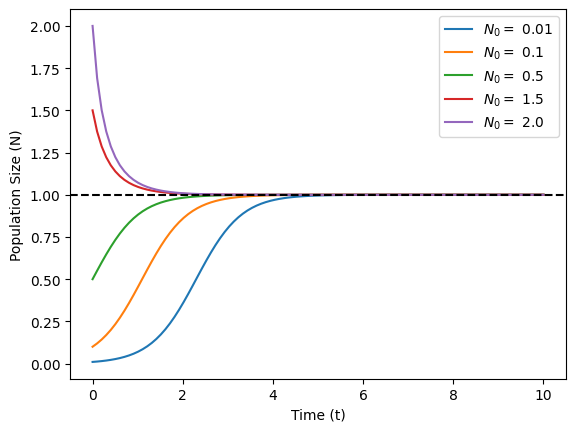

In [11]:
t = np.linspace(0, 10, 100)
r = 2
K = 1

fig, ax =  plt.subplots()
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K

for N0 in N0s:
    N = odeint(modelODE, N0, t, args=(r, K))
    ax.plot(t, N, label=rf"$N_0 =$ {N0}")
ax.axhline(y = K, color = 'k', linestyle = '--')
ax.set_xlabel("Time (t)")
ax.set_ylabel("Population Size (N)")
ax.legend(loc='upper right')

In [6]:
def modelODE_bis(N, t, r, K, gamma):
    return r*N*(1-N/K) - gamma*N

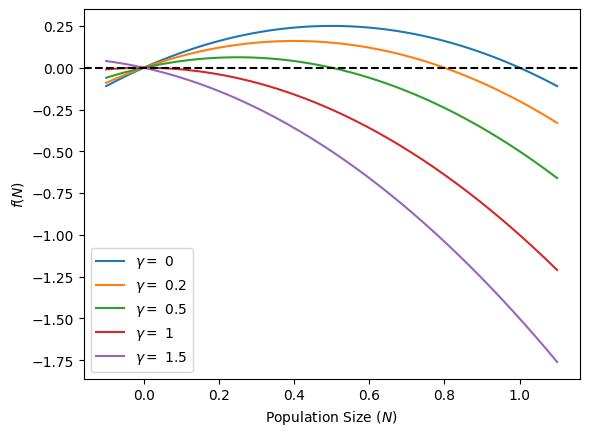

In [12]:
r = 1
K = 1
t = 0

N = np.linspace(-0.1, 1.1, 200)

fig, ax =  plt.subplots()

gammas = [0, 0.2, 0.5, 1, 1.5]

for gamma in gammas:
    f = modelODE_bis(N, t, r, K, gamma)
    ax.plot(N, f, label=rf"$\gamma =$ {gamma}")

ax.axhline(y = 0, color = 'k', linestyle = '--') 

ax.set_xlabel(r"Population Size ($N$)")
ax.set_ylabel(r"$f(N)$")
ax.legend()

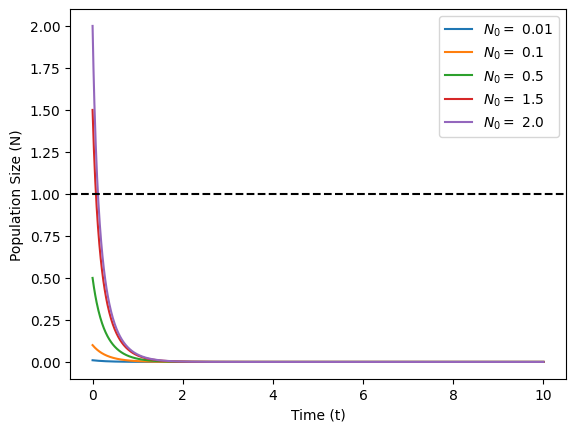

In [13]:
t = np.linspace(0, 10, 1000)
r = 2
K = 1
gamma = 5

fig, ax =  plt.subplots()
N0s = np.array([0.01, 0.1, 0.5, 1.5, 2])*K

for N0 in N0s:
    N = odeint(modelODE_bis, N0, t, args=(r, K, gamma))
    ax.plot(t, N, label=rf"$N_0 =$ {N0}")

ax.axhline(y = 1, color = 'k', linestyle = '--')
ax.set_xlabel("Time (t)")
ax.set_ylabel("Population Size (N)")
ax.legend()